# Tutorial: face transformations with `mozza_mesh`

`mozza_mesh` is a GStreamer plugin that changes **facial expressions** (action units, AUs) and **facial
morphology** (perceived dominance, trustworthiness) on images and live video, for DuckSoup experiments.

- Each transformation is a *field*: how every face landmark moves at amplitude 1. Fields come in
  **basis files** (`gstmozzamesh/bases/`), built and validated in
  [face-transforms](https://github.com/Pablo-Arias/face-transforms).
- You choose **amplitudes** (how much of each transformation), and can change them while a video plays.
- The image is deformed with a **mesh warp**: every landmark lands exactly where the field puts it.

The older plugins (`mozza_mp`, `mozza_mp_gpu`, `.dfm` files) are unchanged; see `tutorial.ipynb`.

**What you'll do:** 1. setup, 2. transform an image with AUs, 3. morphology (dominance, trustworthiness),
4. combine both, 5. video (constant and changing over time), 6. use it in DuckSoup.

---
## 1. Setup

You need Docker running (see `tutorial.ipynb`, section 1) and the plugins image:

In [1]:
!docker pull ducksouplab/mp_plugins:latest
!docker tag ducksouplab/mp_plugins:latest mp_plugins:latest

latest: Pulling from ducksouplab/mp_plugins
Digest: sha256:75b389d198707e5c9a5eb78f96bda725cfe3e31a638d8ba04c69616881659cee
Status: Image is up to date for ducksouplab/mp_plugins:latest


docker.io/ducksouplab/mp_plugins:latest


Until the published image includes `mozza_mesh`, build the plugin once (takes seconds; uses the same base
image as the official build) and the wrapper loads it into the image:

In [2]:
!cd .. && docker build -q --platform linux/amd64 -t mozza-mesh-dev gstmozzamesh/dev
!cd .. && docker run --rm --platform linux/amd64 -v "$PWD":/src -w /src mozza-mesh-dev gstmozzamesh/dev/build.sh

sha256:e6082b9d7f50078516c4e1c966bb91cd9079b5f07bba99d4da928948279f7e13


built: facewarp_cli
libgstmozzamesh.so
video_lm.txt


The MediaPipe model (skip if `face_landmarker.task` is already there):

In [3]:
!cd .. && [ -f face_landmarker.task ] || ./download_face_landmarker_model.sh

In [4]:
import os, sys
sys.path.append("..")
from mesh_process import transform_image, transform_video
from IPython.display import Image as Show, Video, display
from PIL import Image, ImageDraw
import numpy as np

root = os.path.abspath("..")
face = os.path.join(root, "assets", "test_image.jpg")
out = os.path.abspath("output_mesh"); os.makedirs(out, exist_ok=True)

def crop(path, box=(150, 60, 590, 520)):
    return Image.open(path).convert("RGB").crop(box)

def sheet(paths, labels, scale=0.6):
    """Side-by-side images with labels."""
    ims = [crop(p) for p in paths]
    w, h = ims[0].size
    w2, h2 = int(w * scale), int(h * scale)
    s = Image.new("RGB", (w2 * len(ims), h2 + 18), "white")
    d = ImageDraw.Draw(s)
    for i, (im, lab) in enumerate(zip(ims, labels)):
        s.paste(im.resize((w2, h2)), (i * w2, 18)); d.text((i * w2 + 4, 3), lab, fill="black")
    return s

---
## 2. Facial expressions (AUs)

`transform_image(input, output, amplitudes)` takes a dict `{field: amplitude}`. AU amplitudes: **1 = a clear,
plausible expression**, negative values reverse it, combinations add up.

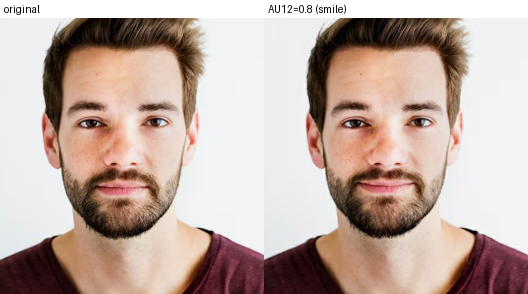

In [5]:
transform_image(face, f"{out}/smile.png", {"AU12": 0.8})
display(sheet([face, f"{out}/smile.png"], ["original", "AU12=0.8 (smile)"]))

All nine AUs of basis v1, at -1 and +1:

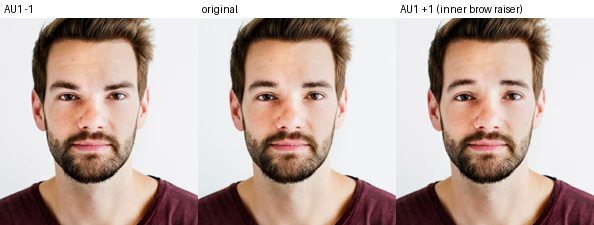

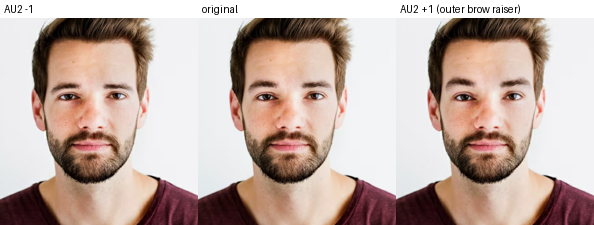

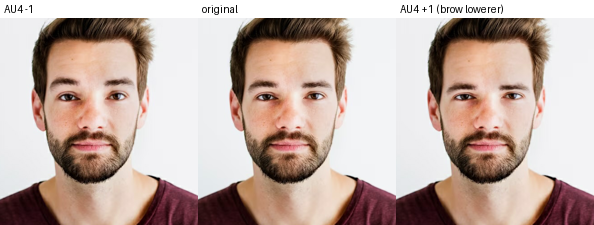

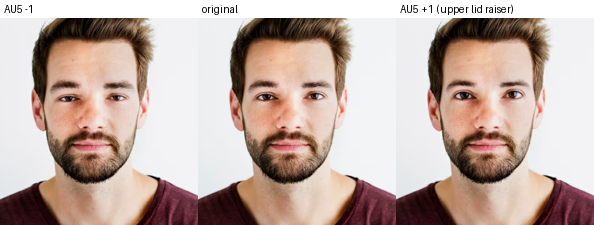

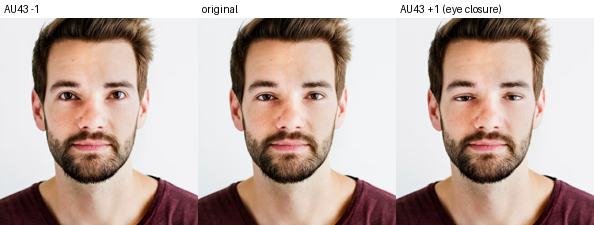

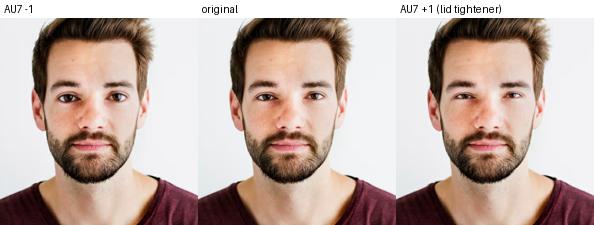

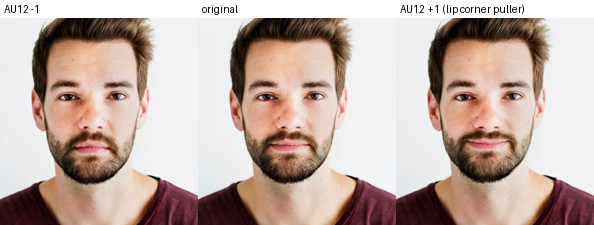

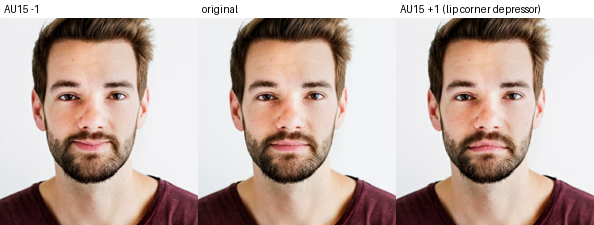

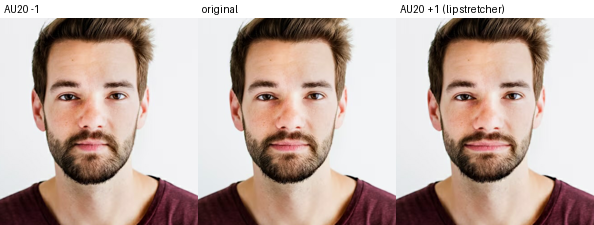

In [6]:
aus = {"AU1": "inner brow raiser", "AU2": "outer brow raiser", "AU4": "brow lowerer",
       "AU5": "upper lid raiser", "AU43": "eye closure", "AU7": "lid tightener",
       "AU12": "lip corner puller", "AU15": "lip corner depressor", "AU20": "lip stretcher"}
for au, name in aus.items():
    paths = []
    for a in (-1, 1):
        p = f"{out}/{au}_{a:+d}.png"; transform_image(face, p, {au: a}); paths.append(p)
    display(sheet([paths[0], face, paths[1]], [f"{au} -1", "original", f"{au} +1 ({name})"], scale=0.45))

---
## 3. Morphology: dominance and trustworthiness

Fields extracted from Oosterhof & Todorov (2008)'s face models. Amplitudes are in **SD** of their models
(the source faces span -3 to +3). `DOM_o` and `TRUST_o` are the orthogonal pair (changing one doesn't change the
other); `DOM`, `TRUST` and `THREAT` are the raw models.

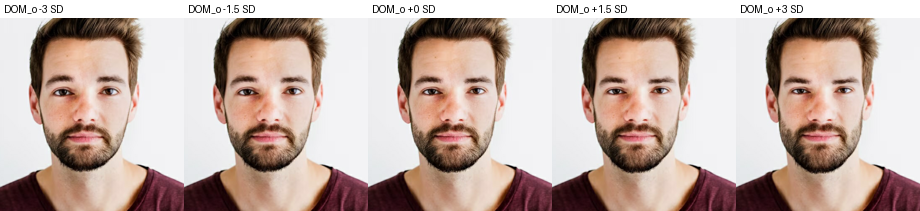

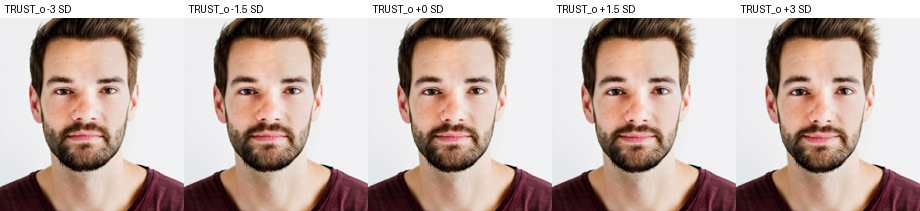

In [7]:
for trait in ("DOM_o", "TRUST_o"):
    paths, labels = [], []
    for sd in (-3, -1.5, 0, 1.5, 3):
        p = f"{out}/{trait}_{sd:+g}.png"
        transform_image(face, p, {trait: sd} if sd else {})
        paths.append(p); labels.append(f"{trait} {sd:+g} SD")
    display(sheet(paths, labels, scale=0.42))

---
## 4. Combining expressions and morphology

Fields from both basis files add up. Here a dominant, untrustworthy face, and the same face smiling:

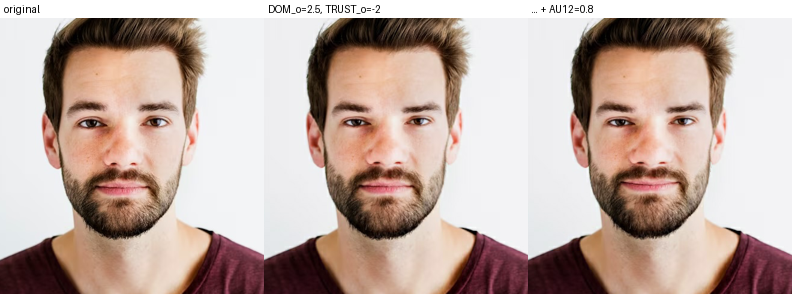

In [8]:
transform_image(face, f"{out}/combo1.png", {"DOM_o": 2.5, "TRUST_o": -2})
transform_image(face, f"{out}/combo2.png", {"DOM_o": 2.5, "TRUST_o": -2, "AU12": 0.8})
display(sheet([face, f"{out}/combo1.png", f"{out}/combo2.png"],
              ["original", "DOM_o=2.5, TRUST_o=-2", "... + AU12=0.8"]))

**Folds.** Strong combinations can make the skin fold over itself (e.g. eye closure + lid tightener at full
strength). The `fold-guard` property (default 5 px²) scales the deformation down for that frame when it would
fold; `transform_image(..., fold_guard=-1)` turns it off.

---
## 5. Video

Constant amplitudes:

In [9]:
video = os.path.join(root, "assets", "video_example.mp4")
transform_video(video, f"{out}/video_smile.mp4", {"AU12": 0.8, "AU1": 0.5})
Video(f"{out}/video_smile.mp4", embed=False, width=480)

**Amplitudes that change over time**: `keyframes=[(seconds, {field: amplitude}), ...]`, interpolated
linearly per frame, exactly what DuckSoup's `controlFx(..., duration)` does. Here: neutral, smile builds up over
1 s, then the smile goes and the face becomes dominant:

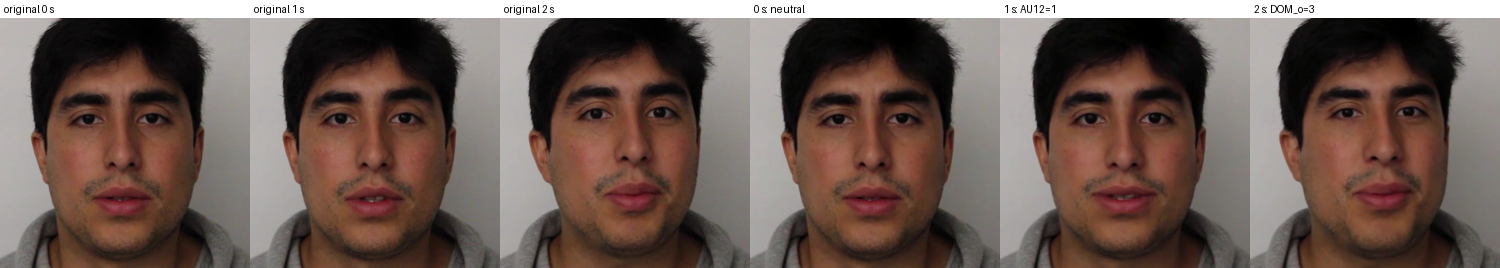

In [10]:
keys = [(0, {"AU12": 0}), (1.0, {"AU12": 1}), (2.0, {"AU12": 0, "DOM_o": 3})]
transform_video(video, f"{out}/video_keyframes.mp4", keyframes=keys)

import cv2
def frame(path, t):
    c = cv2.VideoCapture(path); c.set(cv2.CAP_PROP_POS_FRAMES, int(t * c.get(cv2.CAP_PROP_FPS)))
    ok, f = c.read(); return Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)).crop((562, 112, 982, 532))
ims = [frame(video, t) for t in (0, 1, 2)] + [frame(f"{out}/video_keyframes.mp4", t) for t in (0, 1, 2)]
s = Image.new("RGB", (250 * 6, 268), "white"); d = ImageDraw.Draw(s)
for i, (im, lab) in enumerate(zip(ims, ["original 0 s", "original 1 s", "original 2 s",
                                        "0 s: neutral", "1 s: AU12=1", "2 s: DOM_o=3"])):
    s.paste(im.resize((250, 250)), (250 * i, 18)); d.text((250 * i + 4, 3), lab, fill="black")
display(s)
Video(f"{out}/video_keyframes.mp4", embed=False, width=480)

**Speed.** With `log_every`, the plugin prints the time spent detecting landmarks and warping (here under
x86 emulation on a Mac: much slower than on the server):

In [11]:
transform_video(video, "/tmp/timing.mp4", {"AU12": 0.8}, log_every=30)

docker run --rm --platform linux/amd64 --entrypoint  -u 502:20 -v /Users/arias/Documents/Developement/ducksoup/mp_plugins/assets:/in:ro -v /tmp:/out -v /Users/arias/Documents/Developement/ducksoup/mp_plugins:/repo:ro -e GST_PLUGIN_PATH=/repo/gstmozzamesh/out:/usr/local/lib/gstreamer-1.0:/opt/gstreamer/lib/x86_64-linux-gnu/gstreamer-1.0 -e HOME=/tmp -e GST_DEBUG=mozza_mesh:4 mp_plugins:latest bash -c gst-launch-1.0 -q filesrc location=/in/video_example.mp4 ! qtdemux ! h264parse ! avdec_h264 ! videoconvert ! video/x-raw,format=RGBA ! mozza_mesh model=/repo/face_landmarker.task basis=/repo/gstmozzamesh/bases/au_basis_v1.json,/repo/gstmozzamesh/bases/trait_basis_v1.json amplitudes="AU12=0.8" fold-guard=5.0 show-landmarks=false smooth-landmarks=true log-every=30 ! videoconvert ! x264enc speed-preset=medium ! mp4mux ! filesink location=/out/timing.mp4


W0000 00:00:1791302783.692667       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1791302783.827471      36 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791302783.844477      36 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
0:00:01.877587501          1          1 INFO              mozza_mesh gstmozzamesh.cpp:284:load_basis_locked:<mozzamesh0> basis loaded from '/repo/gstmozzamesh/bases/au_basis_v1.json,/repo/gstmozzamesh/bases/trait_basis_v1.json': AU1, AU12, AU15, AU2, AU20, AU4, AU43, AU5, AU7, DOM, DOM_o, THREAT, TRUST, TRUST_o


0:00:03.474805919          1         37 INFO              mozza_mesh gstmozzamesh.cpp:464:gst_mozza_mesh_transform_frame_ip:<mozzamesh0> TIMING frame=30 detect=35.35ms warp=3.69ms (last fold-guard scale 1.00)


0:00:04.946126169          1         37 INFO              mozza_mesh gstmozzamesh.cpp:464:gst_mozza_mesh_transform_frame_ip:<mozzamesh0> TIMING frame=60 detect=33.91ms warp=2.87ms (last fold-guard scale 1.00)


'/tmp/timing.mp4'

---
## 6. In DuckSoup

Deploy `libgstmozzamesh.so` with the other plugins and the basis files next to `face_landmarker.task`
(see `gstmozzamesh/README.md`). Then name the effect and control it from the experiment page:

```js
videoFx: "mozza_mesh model=/app/plugins/face_landmarker.task " +
         "basis=/app/plugins/au_basis_v1.json,/app/plugins/trait_basis_v1.json name=fx"

ds.controlFx("fx", "au12", 0.8, 500);   // smile appears over 500 ms
ds.controlFx("fx", "dom", 2.0);         // dominant face, immediately
ds.controlFx("fx", "au12", 0, 300);     // smile fades out
ds.polyControlFx("fx", "amplitudes", "string", "AU12=0.5,TRUST_o=1.5");  // any combination
```

Float properties (for `controlFx`, which can interpolate): `au1 au2 au4 au5 au7 au12 au15 au20 au43`,
`trust` (TRUST_o), `dom` (DOM_o), `threat` (THREAT). The `amplitudes` string reaches every field of the loaded
bases. Full property list: `gstmozzamesh/README.md`.